<a href="https://colab.research.google.com/github/ijieun666/UOS_AISW_Colab/blob/main/week01-python-ai-libraries/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 0 — NumPy & Matplotlib Fundamentals (Lecture)

Before we build this week's project below, let's spend some time with the two
libraries you'll use in *every single week* of this course: **NumPy** (fast
numerical arrays) and **Matplotlib** (plotting). This is a hands-on tour
through the core mechanics — array creation, indexing, vectorized math,
broadcasting, and basic plotting — each idea backed by a runnable example.

*(Several examples and figures in this section are adapted from Sebastian
Raschka's [STAT 451: Introduction to Machine Learning](https://github.com/rasbt/stat451-machine-learning-fs20)
course notes, L04: Scientific Computing in Python — used here for teaching purposes.)*

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/numpy-nature-1.png" alt="NumPy as the foundation of the scientific Python stack" style="width: 620px;"/>

NumPy isn't just "one more library" — it's the shared foundation that almost
everything else in the Python data/ML stack (pandas, scikit-learn, PyTorch,
and dozens of domain-specific libraries) is built on top of. Learning NumPy
well pays off in every later week of this course.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 0.1 Why NumPy? Because It's Fast

A Python list stores a collection of separate Python objects scattered around
memory — every arithmetic operation on it has to loop in plain Python, one
slow step at a time. A NumPy array (`ndarray`) instead stores its numbers as
one **contiguous block of raw memory**, all of the same type, so NumPy can
hand the whole computation to fast, compiled C loops instead of the Python
interpreter. Let's measure the difference on a dot product of a million numbers.

### Example: Inner-product between two vectors $x$ and $w$

$$
z = \sum_i x_i w_i = \mathbf{x}^\top \mathbf{w}
$$

In [3]:
import time
import numpy as np

def python_dot(x, w):
    total = 0
    for xi, wi in zip(x, w):
        total += xi * wi
    return total

In [4]:
x_list = list(range(1_000_000)) #[0,1,2,3, ..., 1,000,000]
w_list = list(range(1_000_000)) #[0,1,2,3, ..., 1,000,000]

start = time.time()
python_dot(x_list, w_list)
python_time = time.time() - start
print(f"Pure Python loop:   {python_time:.4f} sec")

Pure Python loop:   0.2070 sec


In [5]:
x_np = np.arange(1_000_000)
w_np = np.arange(1_000_000)

start = time.time()
np.dot(x_np, w_np)
numpy_time = time.time() - start
print(f"NumPy np.dot:       {numpy_time:.4f} sec")

print(f"\nNumPy was about {python_time / numpy_time:.0f}x faster.")

NumPy np.dot:       0.0016 sec

NumPy was about 133x faster.


That speedup (usually 50-150x, depending on the machine) is why almost every
serious numerical/ML library in Python — pandas, scikit-learn, PyTorch — is
built directly on top of NumPy arrays.

## 0.2 Creating Arrays

The most basic way to build an array is `np.array()`, wrapping a Python list
(or list of lists, for 2D). Every array has a few key properties worth
knowing: `dtype` (the type of its elements), `shape` (size along each
dimension), `size` (total element count), and `ndim` (number of dimensions).

In [6]:
ary1d = np.array([1, 2, 3])
ary2d = np.array([[1, 2, 3],
                   [4, 5, 6]])

print("1D array:", ary1d)
print("2D array:\n", ary2d)
print("dtype:", ary2d.dtype)
print("shape:", ary2d.shape)   # (rows, columns)
print("size :", ary2d.size)    # total number of elements
print("ndim :", ary2d.ndim)    # number of dimensions

1D array: [1 2 3]
2D array:
 [[1 2 3]
 [4 5 6]]
dtype: int64
shape: (2, 3)
size : 6
ndim : 2


For a 2D array, `shape` is `(rows, columns)` — NumPy calls the row direction
**axis 0** and the column direction **axis 1**. You'll see `axis=0` /
`axis=1` constantly once we start reducing (summing, averaging, ...) along a
particular direction, so it's worth internalizing this picture now:

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/array_1.png" alt="axis 0 (rows) vs axis 1 (columns) in a 2D array" style="width: 300px;"/>

NumPy also provides shortcuts for building common arrays without typing every
value out by hand: all-ones/all-zeros arrays (handy as placeholders), an
identity matrix, and evenly-spaced number sequences.

In [11]:
print("ones:\n", np.ones((3, 3)))
print("\nzeros:\n", np.zeros((2, 4)))
print("\nidentity matrix (eye):\n", np.eye(3))
print("\narange(0, 10, 2):", np.arange(0, 10, 2))          # like range(), but returns an array
print("linspace(0, 1, num=5):", np.linspace(0, 1, num=5))    # 5 evenly spaced points from 0 to 1

ones:
 [[1. 1. 1.]
 [1. 1. 1.]
 [1. 1. 1.]]

zeros:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]]

identity matrix (eye):
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

arange(0, 10, 2): [0 2 4 6 8]
linspace(0, 1, num=5): [0.   0.25 0.5  0.75 1.  ]


### ⚠  Beware of type correction

Every ndarray has its own type and data we put in the array automatically casted before putting that in the array.

In [12]:
a = np.array([1,2,3,4]).astype(np.int32)
a

array([1, 2, 3, 4], dtype=int32)

In [13]:
a[0] = 3.4
a

array([3, 2, 3, 4], dtype=int32)

## 0.3 Indexing & Slicing

Indexing a NumPy array works a lot like indexing a Python list — with the
extra convenience that for multi-dimensional arrays you can index every
dimension in one set of square brackets, separated by commas: `ary[row, col]`.

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/array_2.png" alt="indexing a 2D array with [row, col], e.g. element [1, 0]" style="width: 300px;"/>

In [16]:
#               -5  -4  -3  -2  -1
# Indices :      0   1   2   3   4
ary = np.array([10, 20, 30, 40, 50])
print("ary[0]  :", ary[0])
print("ary[-1] :", ary[-1])       # last element


ary2d = np.array([[1,  2,  3],
                   [4,  5,  6],
                   [7,  8,  9]])
print("\nary2d[0, 1]  :", ary2d[0, 1])    # row 0, column 1
print("ary2d[-1, -1] :", ary2d[-1, -1])   # bottom-right corner
print("ary2d[0]      :", ary2d[0])        # entire first row


ary[0]  : 10
ary[-1] : 50

ary2d[0, 1]  : 2
ary2d[-1, -1] : 9
ary2d[0]      : [1 2 3]


### Slicing

Slicing extracts a portion of a sequence by specifying a lower and upper bound.
The lower-bound elements is included, but *the upper-bound element is not included;* Mathematically: \[lower, upper).

The step value is optional (default=1) and specifies strides between elements.

$$
var[lower:upper:step]
$$



In [18]:
ary = np.array([10, 20, 30, 40, 50])
print("ary[1:3]:", ary[1:3])      # slice: elements at index 1 and 2
print("ary[::2]:", ary[::2])      # slice: elements from beginning to end with stride=2


ary2d = np.array([[1,  2,  3],
                  [4,  5,  6],
                  [7,  8,  9]])
print("ary2d[:, 0]   :", ary2d[:, 0])     # entire first column
print("ary2d[:2, :2] :\n", ary2d[:2, :2])  # top-left 2x2 block

ary[1:3]: [20 30]
ary[::2]: [10 30 50]
ary2d[:, 0]   : [1 4 7]
ary2d[:2, :2] :
 [[1 2]
 [4 5]]


### Give it a try

Create the array below with the command

$
\text{a = np.arange(25).reshape(5,5)}
$

and extract the slices as indicated.

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/slicing_example.png" alt="NumPy as the foundation of the scientific Python stack" style="width: 620px;"/>


In [27]:
#내가 적은 코드
a = np.arange(25).reshape(5,5)
print("red : \n", a[:, 1:4:2])
print("blue : \n", a[1:4:2,:3:2])

#교수님 코드
red = a[:,1:-1:2]
print("red : \n", red)

blue = a[1:-1:2,:-1:2]
print("blue : \n", blue)

red : 
 [[ 1  3]
 [ 6  8]
 [11 13]
 [16 18]
 [21 23]]
blue : 
 [[ 5  7]
 [15 17]]
red : 
 [[ 1  3]
 [ 6  8]
 [11 13]
 [16 18]
 [21 23]]
blue : 
 [[ 5  7]
 [15 17]]


## 0.6 Views vs. Copies — a Common Gotcha

Basic slicing (like `ary[0]` or `ary[:2, :2]`) does **not** create a new
array in memory — it creates a *view* that still points at the original
data. That's efficient, but it means modifying a slice modifies the
original array too, which can silently cause bugs if you're not expecting it.

In [42]:
original = np.array([[1, 2, 3],
                      [4, 5, 6]])
first_row = original[0]     # a VIEW, not a copy
first_row[0] = 999

print("first_row:", first_row)
print("original (also changed!):\n", original)

first_row: [999   2   3]
original (also changed!):
 [[999   2   3]
 [  4   5   6]]


In [28]:
# Use .copy() when you explicitly want an independent array:
original = np.array([[1, 2, 3],
                      [4, 5, 6]])
safe_copy = original[0].copy()
safe_copy[0] = 999

print("safe_copy:", safe_copy)
print("original (unchanged):\n", original)

safe_copy: [999   2   3]
original (unchanged):
 [[1 2 3]
 [4 5 6]]


In [43]:
print(safe_copy.base)
print(first_row.base)


None
[[999   2   3]
 [  4   5   6]]


One exception: **"fancy indexing"** (indexing with a list/array of indices,
or with a Boolean mask, instead of plain integers/slices) always returns a
copy automatically.

In [46]:
ary = np.array([[1, 2, 3],
                 [4, 5, 6]])
fancy = ary[:, [0, 2]]   # select columns 0 and 2 -- a copy
fancy[0, 0] = -1
print("fancy:\n", fancy)
print("ary (unchanged):\n", ary)

fancy:
 [[-1  3]
 [ 4  6]]
ary (unchanged):
 [[1 2 3]
 [4 5 6]]


## 0.4 Vectorized Math (ufuncs)

Suppose we want to add 1 to every element of a list of lists. The "plain
Python" way needs nested loops:

In [56]:
lst = [[1, 2, 3], [4, 5, 6]]

result = []
for row in lst:
    new_row = []
    for val in row:
        new_row.append(val + 1)
    result.append(new_row)
print("Plain Python loop result:", result)

Plain Python loop result: [[2, 3, 4], [5, 6, 7]]


NumPy's **universal functions** ("ufuncs") do the same element-wise operation
across an entire array in one call — `+`, `-`, `*`, `/`, `**` all work
directly on arrays, plus named functions like `np.add`, `np.exp`, `np.sqrt`.

In [57]:
ary = np.array([[1, 2, 3], [4, 5, 6]])
print("ary + 1:\n", ary + 1)
print("\nary ** 2:\n", ary ** 2)
print("\nnp.sqrt(ary):\n", np.sqrt(ary))

ary + 1:
 [[2 3 4]
 [5 6 7]]

ary ** 2:
 [[ 1  4  9]
 [16 25 36]]

np.sqrt(ary):
 [[1.         1.41421356 1.73205081]
 [2.         2.23606798 2.44948974]]


Many ufuncs can also *reduce* along a chosen axis — collapsing one dimension
by summing (or taking the max, mean, ...) across it. `axis=0` reduces down
the rows (giving one result per column); `axis=1` reduces across the columns
(giving one result per row).

In [58]:
ary = np.array([[1, 2, 3],
                 [4, 5, 6]])
print("column sums (axis=0):", ary.sum(axis=0))
print("row sums    (axis=1):", ary.sum(axis=1))
print("overall sum         :", ary.sum())
print("overall mean        :", ary.mean())

column sums (axis=0): [5 7 9]
row sums    (axis=1): [ 6 15]
overall sum         : 21
overall mean        : 3.5


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/ufunc.png" alt="np.sum(ary, axis=0) vs np.sum(ary, axis=1)" style="width: 520px;"/>

## 0.5 Broadcasting

What if the shapes don't match exactly? NumPy will still try to make an
operation work by mentally "stretching" the smaller array across the larger
one, following a set of rules called **broadcasting** — as long as the
trailing dimensions are either equal or one of them is 1. The simplest case
is a scalar getting applied to every element:

In [59]:
ary = np.array([1, 2, 3])
print("ary + 1 =", ary + 1)

ary + 1 = [2 3 4]


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/broadcasting-1.png" alt="a scalar broadcasts across every element of a 1D array" style="width: 420px;"/>

The same idea extends to a 1D array being broadcast across every row of a 2D array:

In [60]:
matrix = np.array([[4, 5, 6],
                    [7, 8, 9]])
row = np.array([1, 2, 3])   # shape (3,) -- gets applied to every row

print("matrix + row:\n", matrix + row)

matrix + row:
 [[ 5  7  9]
 [ 8 10 12]]


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/broadcasting-2.png" alt="a 1D row vector broadcasts across every row of a 2D matrix" style="width: 420px;"/>

In [61]:
a_row = np.array([1,2,3])
b_col = np.array([[1],[2],[3]])
print(a_row + b_col)

[[2 3 4]
 [3 4 5]
 [4 5 6]]


### Example: image blurring

(400, 300, 4)


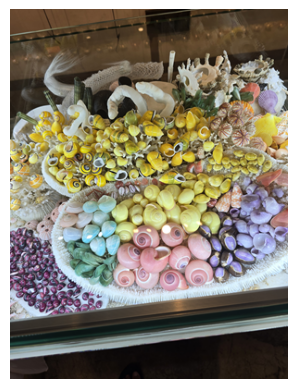

In [62]:
import matplotlib.pyplot as plt
import urllib.request
import io

url = "https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/shells.png"
img = plt.imread(io.BytesIO(urllib.request.urlopen(url).read()), format="png")

print(img.shape)

plt.imshow(img)
plt.axis("off")
plt.show()

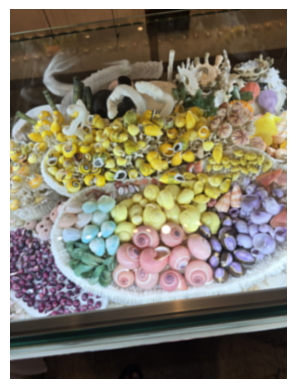

In [63]:
def smooth_loop(img):
    if img.ndim == 3:
        smoothed = np.zeros((img.shape[0] - 2, img.shape[1] - 2, img.shape[2]))
    else:
        smoothed = np.zeros((img.shape[0] - 2, img.shape[1] - 2))
    for r_idx in range(0, img.shape[0] - 2):
        for c_idx in range(0, img.shape[1] - 2):
            smoothed[r_idx, c_idx] = ( img[r_idx+1, c_idx+1]   # center
                                      + img[r_idx,   c_idx+1]  # top
                                      + img[r_idx+2, c_idx+1]  # bottom
                                      + img[r_idx+1, c_idx]    # left
                                      + img[r_idx+1, c_idx+2]  # right
                                      ) / 5.0
    return smoothed

smooth_loop_img = smooth_loop(img)
plt.imshow(smooth_loop_img)
plt.axis("off")
plt.show()

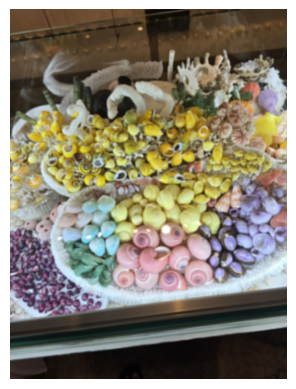

In [67]:
def smooth_numpy(img):
    if img.ndim == 3:
        smoothed = np.zeros((img.shape[0] - 2, img.shape[1] - 2, img.shape[2]))
    else:
        smoothed = np.zeros((img.shape[0] - 2, img.shape[1] - 2))
    smoothed = ( img[1:-1, 1:-1]
                + img[:-2, 1:-1]
                + img[2:, 1:-1]
                + img[1:-1, :-2]
                + img[1:-1, 2:]
                ) / 5.0
    return smoothed

smooth_numpy_img = smooth_numpy(img)
plt.imshow(smooth_numpy_img)
plt.axis("off")
plt.show()


In [ ]:
%timeit smooth_loop(img)
%timeit smooth_numpy(img)

## 0.7 Boolean Masks & `np.where`

Comparing an array to a value produces a **Boolean mask** — a same-shaped
array of `True`/`False` — which you can then use to filter or select values.

In [68]:
ary = np.array([1, 2, 3, 4, 5, 6])
mask = ary > 3
print("mask     :", mask)
print("ary[mask]:", ary[mask])          # only the values where mask is True
print("count    :", mask.sum())          # True counts as 1, False as 0

# combine conditions with & (and) / | (or) -- note the parentheses are required
print("even AND >3:", ary[(ary > 3) & (ary % 2 == 0)])

mask     : [False False False  True  True  True]
ary[mask]: [4 5 6]
count    : 3
even AND >3: [4 6]


In [70]:
# np.where(condition, value_if_true, value_if_false) -- a vectorized if/else
ary = np.array([1, 2, 3, 4, 5, 6])
labels = np.where(ary > 3, "big", "small")
print(labels)
print(np.where(ary > 3))

['small' 'small' 'small' 'big' 'big' 'big']
(array([3, 4, 5]),)


## 0.8 Reshaping

`reshape` lets you rearrange an array's elements into a new shape without
copying or changing the underlying data — as long as the total number of
elements stays the same. Using `-1` for one dimension tells NumPy "figure
this size out for me."

In [71]:
ary = np.arange(1, 13)  # 1, 2, ..., 12
print("original:", ary)
print("reshape(3, 4):\n", ary.reshape(3, 4))
print("reshape(4, -1):\n", ary.reshape(4, -1))    # -1 -> infer this dimension
print("reshape(-1, 2):\n", ary.reshape(-1, 2))
print("flattened back:", ary.reshape(3, 4).flatten())

original: [ 1  2  3  4  5  6  7  8  9 10 11 12]
reshape(3, 4):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
reshape(4, -1):
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
reshape(-1, 2):
 [[ 1  2]
 [ 3  4]
 [ 5  6]
 [ 7  8]
 [ 9 10]
 [11 12]]
flattened back: [ 1  2  3  4  5  6  7  8  9 10 11 12]


## 0.9 A Taste of Linear Algebra

Starting next week, you'll be training models that are, under the hood, just
matrix multiplications — linear regression, neural network layers, all of
it. NumPy's `matmul` (or the `@` operator) and `dot` are the workhorses.

In [75]:
matrix = np.array([[1, 2, 3],
                    [4, 5, 6]])       # shape (2, 3)
vector = np.array([1, 2, 3])          # shape (3,)

print("matrix @ vector:", matrix @ vector)          # same as np.matmul(matrix, vector)

matrix @ vector: [14 32]


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/matmul.png" alt="matrix-vector multiplication: [[1,2,3],[4,5,6]] @ [1,2,3] = [14, 32]" style="width: 420px;"/>

In [76]:
print("matrix.T (transpose):\n", matrix.T)          # shape becomes (3, 2)

matrix.T (transpose):
 [[1 4]
 [2 5]
 [3 6]]


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/transpose.png" alt="transposing a (2,3) matrix into a (3,2) matrix" style="width: 520px;"/>

In [77]:
print("matrix @ matrix.T:\n", matrix @ matrix.T)    # (2,3) @ (3,2) -> (2,2)

matrix @ matrix.T:
 [[14 32]
 [32 77]]


<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/matmatmul.png" alt="matrix multiplied by its own transpose" style="width: 420px;"/>

## 0.10 Random Number Generators

Machine learning uses random numbers constantly — shuffling data,
initializing model weights, generating synthetic datasets (as you'll see in
several of this course's capstone projects). NumPy's random generators are
**seeded**: giving the same seed always reproduces the same sequence of
"random" numbers, which is essential for reproducible experiments.

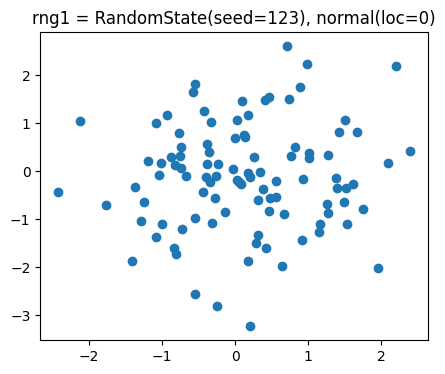

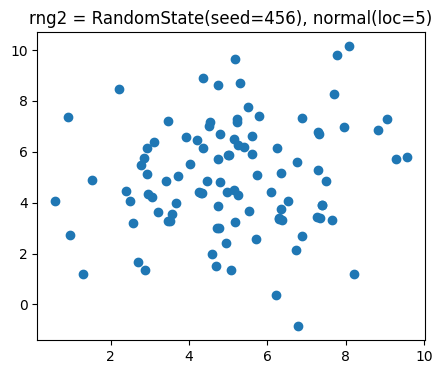

In [78]:
rng1 = np.random.RandomState(seed=123)
points_a = rng1.normal(loc=0, scale=1, size=(100, 2))   # 100 points, mean 0

rng2 = np.random.RandomState(seed=456)
points_b = rng2.normal(loc=5, scale=2, size=(100, 2))   # 100 points, mean 5

plt.figure(figsize=(5, 4))
plt.scatter(points_a[:, 0], points_a[:, 1])
plt.title("rng1 = RandomState(seed=123), normal(loc=0)")
plt.show()

plt.figure(figsize=(5, 4))
plt.scatter(points_b[:, 0], points_b[:, 1])
plt.title("rng2 = RandomState(seed=456), normal(loc=5)")
plt.show()

Different seeds and parameters give different-looking draws (below are two
reference draws for comparison) — but re-running the *same* seed always
reproduces the *exact same* numbers, which is what makes a random experiment
repeatable and debuggable.

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/random_1.png" alt="reference scatter draw, points centered near (0, 0)" style="width: 420px;"/>

<img src="https://raw.githubusercontent.com/vnb987/ai-sw-application-courses-public/main/week01-python-ai-libraries/images/numpy-intro/random_2.png" alt="reference scatter draw, points centered near (5, 5)" style="width: 420px;"/>

## 0.11 Other operations for arrays
### Mathematical functions
* sum, prod

### Sorting
* sort

###Statistics
* mean, std, var
* min, max, argmin, argmax

### Miscellenous
* unravel_index, flatten, ravel

In [81]:
arr = np.array([[1,2,3],
                [4,5,6]])
print("prod : \n", arr.prod())
print("prod : \n", arr.prod(axis=0))
print("prod : \n", arr.prod(axis=1))

random_arr = np.random.random(10)  # 랜덤
sorted = np.sort(random_arr)       # 정렬
print(random_arr)                  # 뒤죽박죽인 원래 랜덤 배열 출력
print(sorted)                      # 순서대로 정렬된 새 배열 출력

arr.mean(axis=0)                   # mean은 평균을 말함.
np.min(arr)
print(np.unravel_index(np.argmax(arr), arr.shape))
                                   # .base는 "너의 진짜 부모(원본 메모리)가 누구니?" 하고 족보를 물어보는 명령어
print(arr.flatten().base)          #.flatten()은 원본 arr과 완전히 인연을 끊고 메모리에 새로운 땅을 파서 복사본
print(arr.ravel().base)            # ravel()은 새롭게 메모리를 쓰지 않고, 원본 arr의 메모리 주소를 그대로 가리킨 채 겉모습만 1차원인 척(View) 하는 기술입니다. 그래서 진짜 부모를 물어보면 원본 배열인 arr의 데이터가 그대로 출력

prod : 
 720
prod : 
 [ 4 10 18]
prod : 
 [  6 120]
[0.83340245 0.58169465 0.6580906  0.12927629 0.07139552 0.24371441
 0.17095709 0.35469589 0.51860894 0.16419645]
[0.07139552 0.12927629 0.16419645 0.17095709 0.24371441 0.35469589
 0.51860894 0.58169465 0.6580906  0.83340245]
(np.int64(1), np.int64(2))
None
[[1 2 3]
 [4 5 6]]


##1. Pandas
Pandas is probablty the most popular and convenient data wrangling library for Python. I allows for heterogeneous data and is specialized for 2D-structured data, especially `csv`. And, as it is built upon NumPy, it offers fast data analysis.

In [82]:
data = {
    "name": ["Ava", "Ben", "Chloe", "Dan", "Ellie", "Finn", "Grace", "Hugo",
              "Ivy", "Jack", "Kira", "Leo", "Mia", "Noah", "Olive"],
    "study_hours": [2, 5, 8, 1, 6, 3, 9, 4, 7, 2, 5, 6, 8, 3, 7],
    "math":    [55, 70, 92, 40, 85, 60, 95, 65, 88, 50, 72, 80, 90, 58, 84],
    "english": [60, 68, 85, 45, 80, 62, 90, 66, 82, 55, 70, 78, 88, 61, 79],
    "science": [58, 72, 90, 42, 83, 59, 96, 67, 86, 52, 74, 79, 92, 60, 82],
    "country": ["USA", "Canada", "Mexico", "USA", "USA", "Mexico","USA", "Mexico", "Canada", "USA", "Canada", "Mexico", "USA", "USA","Canada" ]
}
df = pd.DataFrame(data)
df
df.groupby("country").count()

,name,study_hours,math,english,science
country,,,,,
Canada,4,4,4,4,4
Mexico,4,4,4,4,4
USA,7,7,7,7,7


In [83]:
print("Describe: \n", df.describe())
df.info
print("column head: \n", df.columns)
print("Index: \n", df.index)

Describe: 
        study_hours       math    english    science
count    15.000000  15.000000  15.000000  15.000000
mean      5.066667  72.266667  71.266667  72.800000
std       2.491892  17.060676  13.171759  16.023197
min       1.000000  40.000000  45.000000  42.000000
25%       3.000000  59.000000  61.500000  59.500000
50%       5.000000  72.000000  70.000000  74.000000
75%       7.000000  86.500000  81.000000  84.500000
max       9.000000  95.000000  90.000000  96.000000
column head: 
 Index(['name', 'study_hours', 'math', 'english', 'science', 'country'], dtype='object')
Index: 
 RangeIndex(start=0, stop=15, step=1)


In [90]:
df[df["country"] == "USA"]

,name,study_hours,math,english,science,country
0,Ava,2,55,60,58,USA
3,Dan,1,40,45,42,USA
4,Ellie,6,85,80,83,USA
6,Grace,9,95,90,96,USA
9,Jack,2,50,55,52,USA
12,Mia,8,90,88,92,USA
13,Noah,3,58,61,60,USA


We could filter or choose nessasary values through flexible indexing methods.

In [91]:
df.sort_values("english", ascending=False, inplace=True)
df.head()
corr = df.corr(numeric_only=True)
corr_vals = corr.values.copy()
np.fill_diagonal(corr_vals, 0)
df.groupby("country")["math"].mean()


,math
country,
Canada,78.500000
Mexico,74.250000
USA,67.571429


##2. Matplotlib Basics
Matplotlib is the standard plotting library in the Python data/ML stack. Its
core object is `pyplot` (`plt`), and its most common building blocks are line
plots, scatter plots, bar charts, and histograms.

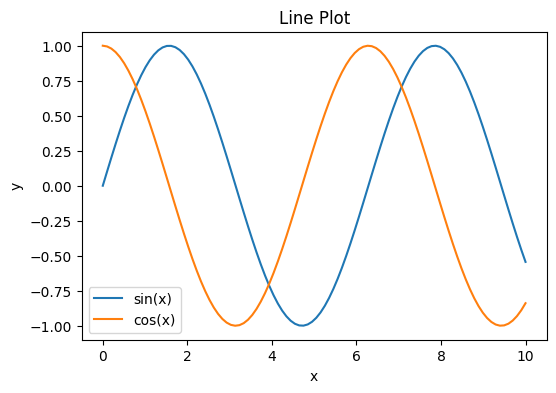

In [92]:
x = np.linspace(0, 10, 100)

plt.figure(figsize=(6, 4))
plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.title("Line Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

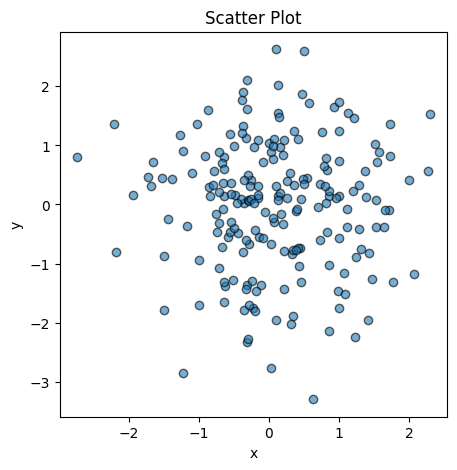

In [93]:
rng = np.random.default_rng(123)
x = rng.normal(0, 1, 200)
y = rng.normal(0, 1, 200)

plt.figure(figsize=(5, 5))
plt.scatter(x, y, alpha=0.6, edgecolor="k")
plt.title("Scatter Plot")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

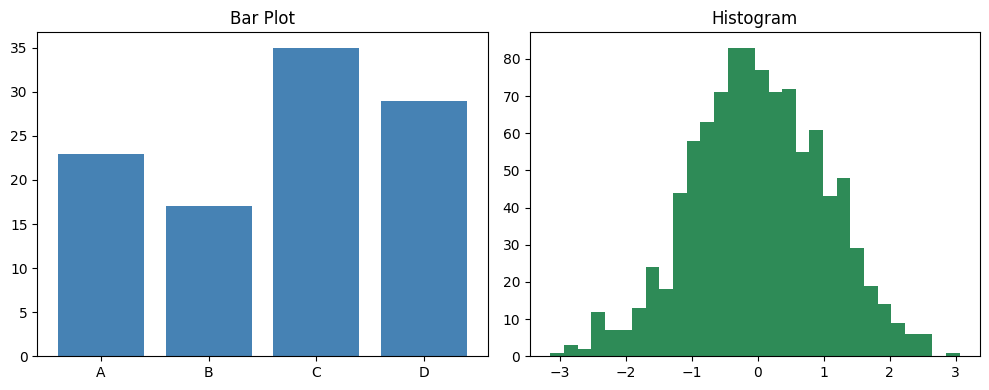

In [94]:
categories = ["A", "B", "C", "D"]
values = [23, 17, 35, 29]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(categories, values, color="steelblue")
axes[0].set_title("Bar Plot")

axes[1].hist(rng.normal(0, 1, 1000), bins=30, color="seagreen")
axes[1].set_title("Histogram")
plt.tight_layout()
plt.show()

---

With these fundamentals in hand, let's put them to work in a real (if small)
data-analysis project below.

# Week 1 — Student Exam Score Explorer

**Theme:** Course intro & major Python AI libraries (NumPy, pandas, matplotlib)

Every AI project starts the same way: load some data, look at it, and ask simple
questions. In this notebook you'll practice that with a made-up class roster —
study hours and exam scores for 15 students — using the three libraries you'll
use constantly for the rest of the course.

**By the end of this notebook you will be able to:**
- Build and inspect a `pandas` DataFrame
- Compute summary statistics with `NumPy` and `pandas`
- Filter, sort, and group tabular data
- Visualize a dataset with `matplotlib`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("numpy:", np.__version__)
print("pandas:", pd.__version__)

## 1. Create the dataset

No file download needed — we build a small dataset directly in Python so this
notebook always runs, even offline. In a real project this cell would instead
be `pd.read_csv("your_file.csv")`.

In [ ]:
data = {
    "name": ["Ava", "Ben", "Chloe", "Dan", "Ellie", "Finn", "Grace", "Hugo",
              "Ivy", "Jack", "Kira", "Leo", "Mia", "Noah", "Olive"],
    "study_hours": [2, 5, 8, 1, 6, 3, 9, 4, 7, 2, 5, 6, 8, 3, 7],
    "math":    [55, 70, 92, 40, 85, 60, 95, 65, 88, 50, 72, 80, 90, 58, 84],
    "english": [60, 68, 85, 45, 80, 62, 90, 66, 82, 55, 70, 78, 88, 61, 79],
    "science": [58, 72, 90, 42, 83, 59, 96, 67, 86, 52, 74, 79, 92, 60, 82],
}
df = pd.DataFrame(data)
df

## 2. First look with pandas

`.head()`, `.info()`, and `.describe()` are usually the first three commands you
run on any new dataset.

In [ ]:
df.info()

In [ ]:
df.describe()

## 3. NumPy: fast numeric computation

`pandas` is built on top of NumPy — pulling a column out of a DataFrame gives you
a NumPy array, and NumPy gives you fast statistics on it.

In [ ]:
math_scores = df["math"].to_numpy()

print("mean :", np.mean(math_scores))
print("std  :", np.std(math_scores))
print("max  :", np.max(math_scores), "-> student:", df.loc[df["math"].idxmax(), "name"])
print("min  :", np.min(math_scores), "-> student:", df.loc[df["math"].idxmin(), "name"])

In [ ]:
# Does studying more actually correlate with a higher math score?
correlation = np.corrcoef(df["study_hours"], df["math"])[0, 1]
print(f"Correlation between study hours and math score: {correlation:.2f}")

## 4. pandas: filter, sort, group

A "pass" is an average score of 70 or higher across the three subjects.

In [ ]:
df["average"] = df[["math", "english", "science"]].mean(axis=1)
df["passed"] = df["average"] >= 70

df.sort_values("average", ascending=False)

In [ ]:
# How many students passed vs. failed?
df["passed"].value_counts()

In [ ]:
# Average score per subject, reshaped so each row is one subject
subject_avg = df[["math", "english", "science"]].mean().rename("average_score")
subject_avg

## 5. matplotlib: see the data

Numbers in a table are hard to read at a glance — a plot makes patterns obvious.

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(df["math"], bins=6, color="steelblue", edgecolor="white")
plt.title("Distribution of Math Scores")
plt.xlabel("Score")
plt.ylabel("Number of students")
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(df["study_hours"], df["math"], color="darkorange", label="math score")
plt.plot(df["study_hours"], df["english"], color="blue", label="english score")
plt.legend()
plt.title("Study Hours vs. Math Score")
plt.xlabel("Study hours per week")
plt.ylabel("Math score")
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(subject_avg.index, subject_avg.values, color=["steelblue", "darkorange", "seagreen"])
plt.title("Average Score by Subject")
plt.ylabel("Average score")
plt.ylim(0, 100)
plt.show()

## Try it yourself

Add a new code cell below and try:

1. **Add yourself to the class.** Append a new row to `df` with your own
   `study_hours` and (made-up) scores, then re-run the plots.
2. **Which subject correlates most with study hours?** Compute
   `np.corrcoef(df["study_hours"], df[subject])` for `english` and `science` too,
   and compare to the `math` correlation above.
3. **Boxplot.** Use `plt.boxplot([df["math"], df["english"], df["science"]])`
   to compare the spread of scores across subjects in one chart.
4. **Top 3 students.** Use `.sort_values()` and `.head(3)` to print the names of
   the top 3 students by `average`.

---
## 🎯 캡스톤: 나만의 학기 생활 로그 분석기

지금까지는 이미 만들어진 학급 데이터를 분석했습니다. 이번엔 **90일치 대학생활 로그(공부시간·수면시간·지출·기분)** 더미 데이터를 드릴 테니, 위에서 배운 numpy/pandas/matplotlib만 사용해서 **직접** 분석해보세요. 정답 코드는 없습니다 — 아래 힌트를 참고해서 스스로 채워 넣으세요.

**확장 아이디어:** 나중에 실제로 한 달간 본인의 공부시간/지출을 기록해서 `log_df`를 실제 데이터로 바꿔치기하면, 이 코드가 그대로 "내 생활 분석기"가 됩니다.

In [ ]:
# 더미 데이터 생성 (실행만 하면 됩니다 -- 이 셀은 그대로 두세요)
rng = np.random.default_rng(42)
n_days = 90
dates = pd.date_range("2026-03-02", periods=n_days, freq="D")

is_weekend = dates.dayofweek >= 5
study_hours = np.clip(rng.normal(np.where(is_weekend, 2.5, 5.0), 1.3), 0, 12)
sleep_hours = np.clip(rng.normal(np.where(is_weekend, 8.5, 6.5), 1.0), 3, 11)
expense_won = np.clip(rng.normal(np.where(is_weekend, 35000, 15000), 8000), 0, None).round(-2)
mood = np.clip(np.round(rng.normal(np.where(is_weekend, 4.0, 3.0), 1.0)), 1, 5).astype(int)

log_df = pd.DataFrame({
    "date": dates,
    "study_hours": study_hours.round(1),
    "sleep_hours": sleep_hours.round(1),
    "expense_won": expense_won.astype(int),
    "mood": mood,
})
log_df.head()

### 여러분의 과제

아래 빈 셀에 직접 코드를 작성해서 다음을 해보세요 (순서/방법은 자유입니다):

1. **요일별 평균 공부시간**을 구해보세요. (힌트: `log_df["date"].dt.day_name()` 또는 `dt.dayofweek`로 요일 컬럼을 만들고 `groupby().mean()`)
2. **지출(`expense_won`)이 가장 많았던 상위 3일**을 찾아 출력해보세요. (힌트: `sort_values()`, `head(3)`)
3. **수면시간과 공부시간의 상관관계**를 계산해보세요. (힌트: `np.corrcoef()` 또는 `log_df[[...]].corr()`)
4. 평균이상의 지출을 했을때와 아닐 때의 평균 공부시간을 출력해보세요.
5. **(자유 과제)** 여러분만의 "생산성 지수"를 직접 정의해보세요. 예: `study_hours * 2 - abs(sleep_hours - 7)`. 이 지수가 가장 높았던 날 Top 3는 언제인가요?

In [ ]:
# TODO 1: 요일별 평균 공부시간을 구해보세요.

# TODO 2: 지출이 가장 많았던 상위 3일을 출력해보세요.

# TODO 3: 수면시간과 공부시간의 상관관계를 계산해보세요.

# TODO 4: 평균이상의 지출을 했을때와 아닐 때의 평균 공부시간을 출력해보세요.

# TODO 5 (자유 과제): 나만의 "생산성 지수"를 정의하고,